In [1]:
# If you are using colab, you can mount your google drive and access data from there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessing
We interpolate then normalize the data. Each is done individually

In [2]:
# Replace with your own files
#!cp "/content/drive/My Drive/ramandata/conor/Train_Inputs.mat" .
#!cp "/content/drive/My Drive/ramandata/conor/Test_Inputs.mat" .

In [3]:
import scipy.io
import os
import numpy as np
import h5py

file_path = '/content/drive/MyDrive/Tesi_Raman/Datasets/Paper RamanMAE/Dataset_2_Cancer_Cell.mat'
print('Loading Dataset 2 (Cells)...')

# 1. Loading and variable selection
try:
    mat = scipy.io.loadmat(file_path)
    X_raw_all = mat['All_filt']
    asse_X_orig = mat['wn'].flatten()
    status = mat['labels_table_status_cell1_bg0'].flatten()
    labels_pheno = mat['labels_table_class'].flatten()
    group_cell_id = mat['labels_table_cell'].flatten()
except Exception:
    # Fallback in case the file is in v7.3 format
    with h5py.File(file_path, 'r') as f:
        X_raw_all = np.array(f['All_filt']).T
        asse_X_orig = np.array(f['wn']).flatten()
        status = np.array(f['labels_table_status_cell1_bg0']).flatten()
        labels_pheno = np.array(f['labels_table_class']).flatten()
        group_cell_id = np.array(f['labels_table_cell']).flatten()

# 2. "TRUE CELLULAR SPECTRA" FILTER (Status 1)
print('Filtering spectra: background removal (Status 0)...')
is_cell = (status == 1)
X_step1 = X_raw_all[is_cell, :]
labels_step1 = labels_pheno[is_cell]
groups_step1 = group_cell_id[is_cell]

# 3. "DATA QUALITY" FILTER (NaN removal)
print('Quality filter: removing rows with NaN...')
righe_senza_nan = ~np.isnan(X_step1).any(axis=1)
X_raw = X_step1[righe_senza_nan, :]
labels_final = labels_step1[righe_senza_nan]
groups_final = groups_step1[righe_senza_nan]
asse_X = asse_X_orig

print(f"Remaining spectra after filters: {X_raw.shape[0]}")
print(f"X-axis shape: {asse_X.shape}")

Loading Dataset 2 (Cells)...


/usr/local/lib/python3.12/dist-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Filtering spectra: background removal (Status 0)...
Quality filter: removing rows with NaN...
Remaining spectra after filters: 15429
X-axis shape: (871,)


In [4]:
# This code is no longer necessary as the X-axis is extracted from TROPHY.mat as asse_X

# def read_axis(filename):
#     """Read the wavelength axis from file."""
#     with open(filename, 'r') as f:
#         wavelengths = np.array([float(line.strip()) for line in f])
#     return wavelengths

# wavelengths = read_axis("/content/drive/My Drive/ramandata/conor/axis.txt")


In [5]:
from scipy import interpolate
from tqdm import tqdm

def interpolate_spectra(spectra_data, old_wavelengths, target_wavelengths):
    # Initialize array for interpolated spectra
    interpolated_spectra = np.zeros((spectra_data.shape[0], len(target_wavelengths)))

    # Interpolate each spectrum
    for i in tqdm(range(spectra_data.shape[0])):
        # Create cubic spline interpolation function
        f = interpolate.CubicSpline(old_wavelengths, spectra_data[i, :])

        # Apply interpolation to new wavelength points
        interpolated_spectra[i, :] = f(target_wavelengths)

    return interpolated_spectra, target_wavelengths

In [6]:
def normalize_raman_spectra(spectra):
    # Create output array
    normalized = np.zeros_like(spectra)

    # Normalize each spectrum individually
    for i in tqdm(range(spectra.shape[0])):
        spectrum = spectra[i, :]
        min_val = np.min(spectrum)
        max_val = np.max(spectrum)

        # Min-max normalization to [0,1] range
        normalized[i, :] = (spectrum - min_val) / (max_val - min_val)

    return normalized

In [7]:
# Adapt X-axis to 1D format
asse_X_flat = asse_X.flatten()

# Global parameters for the new wavelength axis
MIN_WAVE = 650
MAX_WAVE = 1750
NUM_PUNTI = 1000

# Creation of the new equally spaced target axis
asse_target = np.linspace(MIN_WAVE, MAX_WAVE, NUM_PUNTI)
print(f"New target axis created: from {MIN_WAVE} to {MAX_WAVE} with {NUM_PUNTI} points.")

# Interpolate using the targeted axis
interpolated_spectra, new_wavelengths = interpolate_spectra(
    X_raw,
    asse_X_flat,
    target_wavelengths=asse_target
)

New target axis created: from 650 to 1750 with 1000 points.


100%|██████████| 15429/15429 [00:05<00:00, 2934.07it/s]


In [8]:
normalized_spectra = normalize_raman_spectra(interpolated_spectra)
normalized_spectra.shape

100%|██████████| 15429/15429 [00:00<00:00, 57379.80it/s]


(15429, 1000)

In [9]:
import os

# Requested save path
save_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max'
os.makedirs(save_dir, exist_ok=True) # Create folder if it doesn't exist

save_path = os.path.join(save_dir, 'CELLS_1000pt_FingerPrint.npz')

# Save the normalized spectra, new x-axis, labels and groups as float32
np.savez(save_path,
          spectra=normalized_spectra.astype(np.float32),
          wavelengths=new_wavelengths.astype(np.float32),
          labels=labels_final,
          groups=groups_final)

print(f"Dataset 2 (Cells) standardized and saved in: {save_path}")

Dataset 2 (Cells) standardized and saved in: /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/CELLS_1000pt_FingerPrint.npz


In [10]:
# Verification step: Load the saved data to confirm the wavelength range and shapes
import numpy as np

# Load the previously saved .npz file
loaded_data = np.load(save_path)

saved_wavelengths = loaded_data['wavelengths']
saved_spectra = loaded_data['spectra']

print("--- Verification of Saved Data ---")
print(f"File loaded from: {save_path}")
print(f"Saved wavelengths range: min = {saved_wavelengths.min():.2f} cm^-1, max = {saved_wavelengths.max():.2f} cm^-1")
print(f"Number of wavelength points: {len(saved_wavelengths)}")
print(f"Saved spectra shape: {saved_spectra.shape}")

# Quick validation check
if saved_wavelengths.min() >= MIN_WAVE and saved_wavelengths.max() <= MAX_WAVE:
    print("\n✅ Success: The saved data is perfectly within the requested range!")
else:
    print("\n❌ Warning: The saved data is outside the requested range.")

--- Verification of Saved Data ---
File loaded from: /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/CELLS_1000pt_FingerPrint.npz
Saved wavelengths range: min = 650.00 cm^-1, max = 1750.00 cm^-1
Number of wavelength points: 1000
Saved spectra shape: (15429, 1000)

✅ Success: The saved data is perfectly within the requested range!


# Plot Comparison
These plots are used in Several figures throughout the RamanFoundation paper

In [11]:
import matplotlib.pyplot as plt
plt.style.use('default')

FONTSIZE_AXIS = 15
FONTSIZE_TITLE=15

In [12]:
# Helpers
def get_spectra_from_range(spectra, wavelengths, wavelength_range):
  # Find indices of wavelengths within the range
  indices = np.where((wavelengths >= wavelength_range[0]) &
                     (wavelengths <= wavelength_range[1]))[0]

  # Extract the corresponding spectra
  extracted_spectra = spectra[indices]
  extracted_wavelengths = wavelengths[indices]

  return extracted_wavelengths, extracted_spectra

This plot is used to provide an example of interpolation in Figure 3

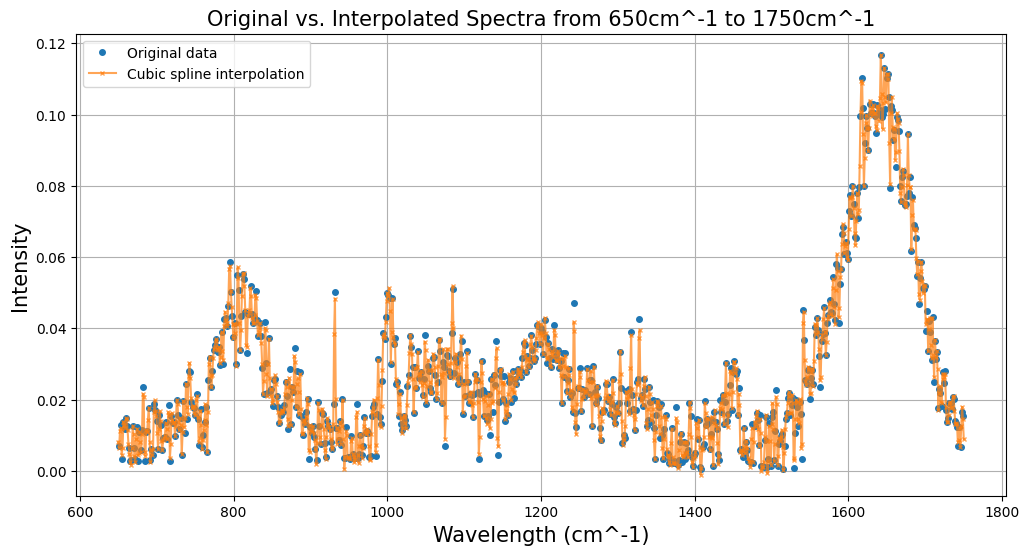

In [13]:
wavelength_range = (MIN_WAVE, MAX_WAVE) # Modified for the new range
sample_idx = 0

training_sample = X_raw[sample_idx]
interpolated_sample = interpolated_spectra[sample_idx]

wavelengths_original, spectra_original = get_spectra_from_range(training_sample, asse_X_flat, wavelength_range)
wavelengths_interpolated, spectra_interpolated = get_spectra_from_range(interpolated_sample, new_wavelengths, wavelength_range)

plt.figure(figsize=(12,6))
plt.plot(wavelengths_original, spectra_original,
        'o', label='Original data', markersize=4) # Reduced markersize to better view numerous points
plt.plot(wavelengths_interpolated, spectra_interpolated,
          'x-', label='Cubic spline interpolation', alpha=0.7, markersize=3) # Restored 'x' marker for interpolated points

plt.xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
plt.ylabel('Intensity', fontsize=FONTSIZE_AXIS)
plt.title(f'Original vs. Interpolated Spectra from {wavelength_range[0]}cm^-1 to {wavelength_range[1]}cm^-1', fontsize=FONTSIZE_TITLE)
plt.legend()
plt.grid(True)
plt.show()

This plot is used to show normalization in Figure 3

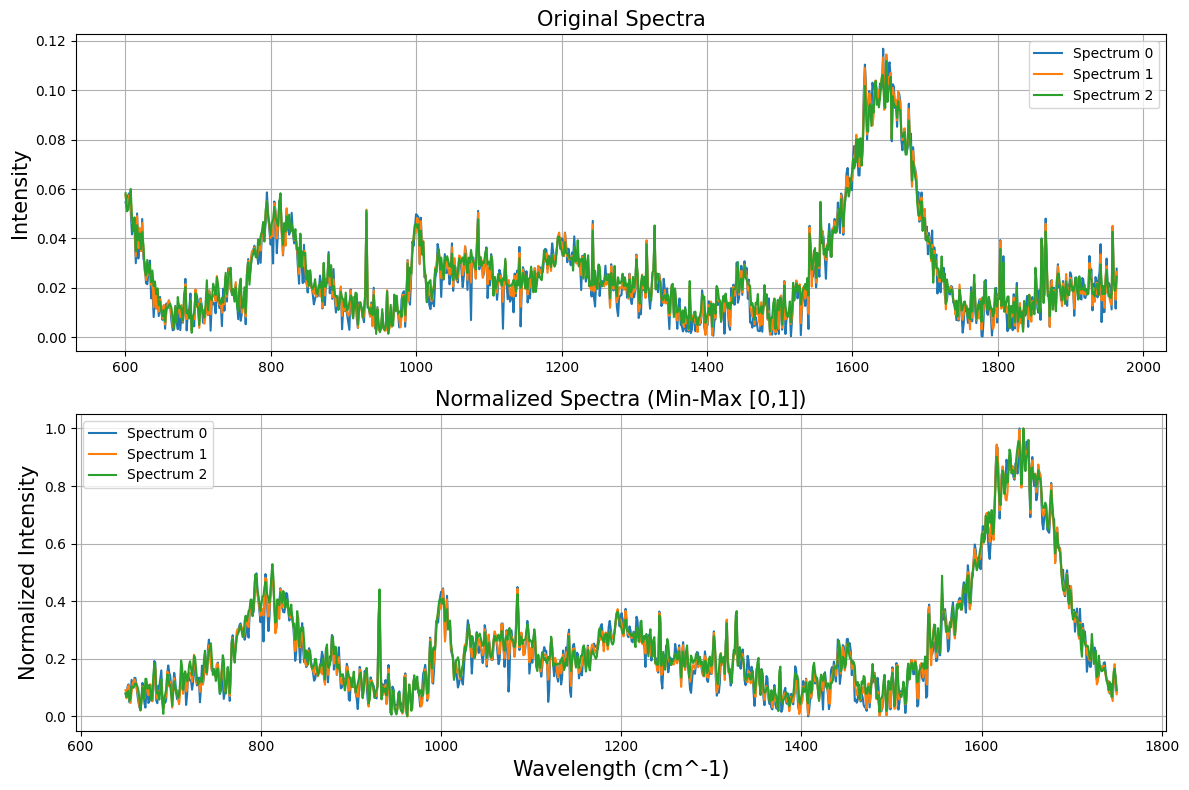

In [14]:
def plot_normalization_comparison(original_spectra, normalized_spectra, sample_indices=[0,1,2]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot original spectra
    for idx in sample_indices:
        ax1.plot(asse_X_flat, original_spectra[idx], label=f'Spectrum {idx}')
    ax1.set_title('Original Spectra', fontsize=FONTSIZE_TITLE)
    # ax1.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax1.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
    ax1.legend()
    ax1.grid(True)

    # Plot normalized spectra
    for idx in sample_indices:
        ax2.plot(new_wavelengths, normalized_spectra[idx], label=f'Spectrum {idx}')
    ax2.set_title('Normalized Spectra (Min-Max [0,1])', fontsize=FONTSIZE_TITLE)
    ax2.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax2.set_ylabel('Normalized Intensity', fontsize=FONTSIZE_AXIS)
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


# Plot comparison
plot_normalization_comparison(X_raw, normalized_spectra)

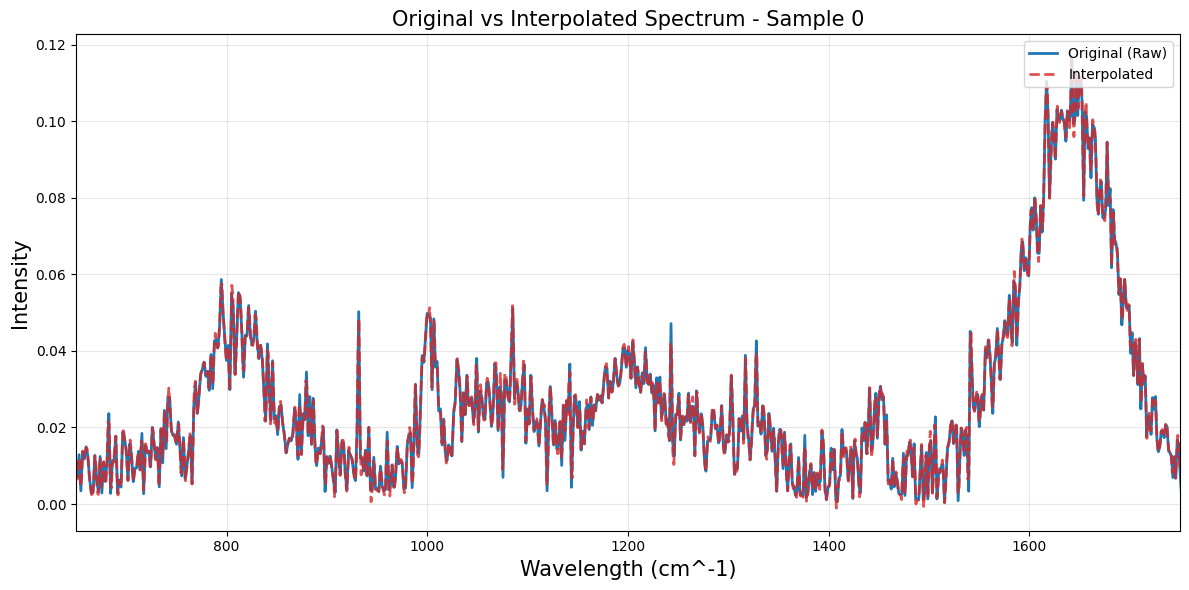

In [15]:
# Overlay of original and interpolated spectra to verify shape preservation
sample_idx = 0
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Original Spectrum
ax.plot(asse_X_flat, X_raw[sample_idx], color='tab:blue', label='Original (Raw)', linewidth=2)

# Plot Interpolated Spectrum
ax.plot(new_wavelengths, interpolated_spectra[sample_idx], color='tab:red', linestyle='--', alpha=0.8, label='Interpolated', linewidth=2)

# Formatting the plot
ax.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
ax.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
ax.set_xlim([MIN_WAVE, MAX_WAVE])
ax.set_title(f'Original vs Interpolated Spectrum - Sample {sample_idx}', fontsize=FONTSIZE_TITLE)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()